# Assignment 2 — Discrete and Continuous Probability Models

**Course:** Statistics and Data Analysis for Engineers (STA1)

**Group members:** Bibek Paudel, Dora Buruncuk, Supendra Bogati

## Table of contents

1. [Part 1 — Cooling-unit failures: a finite random variable](#part1)
2. [Part 2 — Repeated-event count models](#part2)
3. [Part 3 — Uniform and normal models](#part3)
4. [Part 4 — Service restoration: an exponential working model](#part4)
5. [Part 5 — AI-use and conclusion](#part5)

Only methods from Sessions 3 and 4 are used: finite, binomial and Poisson models for counts, and
uniform, normal and exponential models for continuous measurements.

In [1]:
%matplotlib inline

from math import comb

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import binom, poisson

DATA = "data/"

concrete = pd.read_csv(DATA + "assignment02_concrete_strength.csv")   # Part 3
repairs = pd.read_csv(DATA + "assignment02_service_repairs.csv")     # Part 4

print(f"concrete: {concrete.shape[0]} rows x {concrete.shape[1]} columns")
print(f"repairs: {repairs.shape[0]} rows x {repairs.shape[1]} columns")

concrete: 160 rows x 2 columns
repairs: 180 rows x 2 columns


<a id="part1"></a>
# Part 1 — Cooling-unit failures: a finite random variable

> Let $X$ be the number of cooling units that fail during a weekly maintenance window. The
> engineering model is

| $x$ | 0 | 1 | 2 | 3 | 4 |
|---|---|---|---|---|---|
| $P(X = x)$ | 0.58 | 0.26 | 0.10 | 0.04 | 0.02 |

## a)

> Verify that the table is a valid PMF, state the support, and distinguish the random variable $X$
> from an observed value $x$.


$$0 \le p_X(x) \le 1 \quad \text{for every } x, \qquad \sum_x p_X(x) = 1$$

In [2]:
x = np.array([0, 1, 2, 3, 4])
pmf = np.array([0.58, 0.26, 0.10, 0.04, 0.02])

print("Every p_X(x) between 0 and 1:", np.all((pmf >= 0) & (pmf <= 1)))
print("Sum of all p_X(x):", pmf.sum())

Every p_X(x) between 0 and 1: True
Sum of all p_X(x): 1.0


**Valid PMF:** every probability lies between 0 and 1, and together they add to exactly 1, so the
table is a valid PMF.

**Support:** the set of values $X$ can take with positive probability,

$$\text{supp}(X) = \{0, 1, 2, 3, 4\}$$

**$X$ versus $x$:** $X$ is the random variable: the number of cooling units that will fail in a
coming week. Before the week it is unknown and could be anything from 0 to 4. $x$ is an observed
value: the number that actually failed once the week is over, for example $x = 1$. $X$ is
uncertain, while $x$ is a fixed number.

## b)

> Construct a table containing $x$, $p_X(x)$, and $F_X(x)$. Use it to calculate $P(X = 2)$,
> $P(X \le 1)$, $P(X \ge 2)$, and $P(1 < X \le 3)$.

$$F_X(x) = P(X \le x) = \sum_{k \le x} p_X(k)$$

In [3]:
cdf = np.cumsum(pmf)

table = pd.DataFrame({"x": x, "p_X(x)": pmf, "F_X(x)": cdf}).set_index("x")
table

,p_X(x),F_X(x)
x,,
0,0.58,0.58
1,0.26,0.84
2,0.10,0.94
3,0.04,0.98
4,0.02,1.00


$$P(X = 2) = p_X(2)$$

$$P(X \le 1) = F_X(1)$$

$$P(X \ge 2) = 1 - P(X \le 1) = 1 - F_X(1)$$

$$P(1 < X \le 3) = F_X(3) - F_X(1)$$

Because $X$ only takes whole numbers, "$X \ge 2$" is the complement of "$X \le 1$", and
"$1 < X \le 3$" means $X$ is 2 or 3.

In [4]:
# x runs from 0 to 4, so position i in each array holds the value for x = i.
print(f"P(X = 2)      = p_X(2)          = {pmf[2]:.2f}")
print(f"P(X <= 1)     = F_X(1)          = {cdf[1]:.2f}")
print(f"P(X >= 2)     = 1 - F_X(1)      = {1 - cdf[1]:.2f}")
print(f"P(1 < X <= 3) = F_X(3) - F_X(1) = {cdf[3] - cdf[1]:.2f}")

P(X = 2)      = p_X(2)          = 0.10
P(X <= 1)     = F_X(1)          = 0.84
P(X >= 2)     = 1 - F_X(1)      = 0.16
P(1 < X <= 3) = F_X(3) - F_X(1) = 0.14


**Interpretation:** most weeks (84 %) have at most one failure, and 16 % have two or more.

## c)

> Plot the PMF as a bar chart and the CDF as a step plot. Explain the meaning of the height at each
> value in both plots.

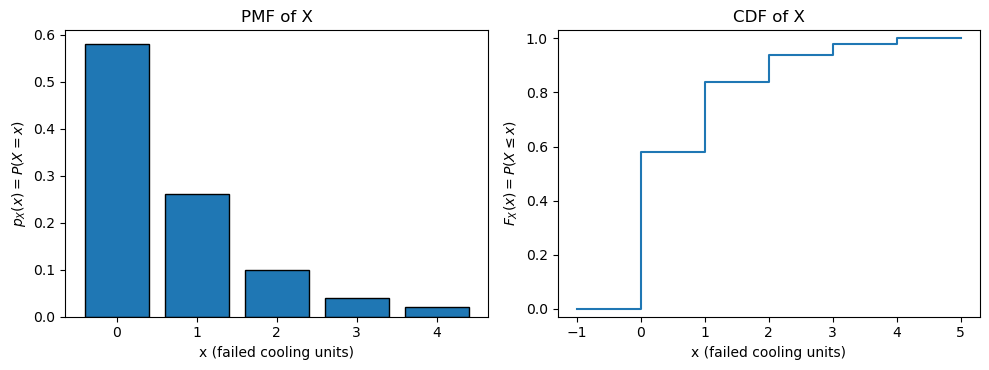

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))

ax[0].bar(x, pmf, edgecolor="black")
ax[0].set(title="PMF of X", xlabel="x (failed cooling units)", ylabel=r"$p_X(x) = P(X = x)$")

# Extend one step past each end: F is 0 before x = 0 and 1 after x = 4.
x_step = np.concatenate([[-1], x, [5]])
cdf_step = np.concatenate([[0], cdf, [1]])

ax[1].step(x_step, cdf_step, where="post")
ax[1].set(title="CDF of X", xlabel="x (failed cooling units)", ylabel=r"$F_X(x) = P(X \leq x)$",
          ylim=(-0.03, 1.03))

plt.tight_layout()
plt.show()

**PMF (left):** the height of the bar at $x$ is $p_X(x) = P(X = x)$, the probability that
**exactly** $x$ units fail in a week.

**CDF (right):** the height of the step at $x$ is $F_X(x) = P(X \le x)$, the probability that
**at most** $x$ units fail. Each jump in the CDF equals the height of the PMF bar at that value.

## d)

> Calculate and interpret $E[X]$, $\text{Var}(X)$, and $\text{SD}(X)$.

$$E[X] = \sum_x x \, p_X(x)$$

$$\text{Var}(X) = E[X^2] - (E[X])^2, \qquad E[X^2] = \sum_x x^2 \, p_X(x)$$

$$\text{SD}(X) = \sqrt{\text{Var}(X)}$$

In [6]:
mean = np.sum(x * pmf)
mean_sq = np.sum(x**2 * pmf)        # E[X^2]
variance = mean_sq - mean**2
sd = np.sqrt(variance)

print(f"E[X]   = {mean:.2f}")
print(f"E[X^2] = {mean_sq:.2f}")
print(f"Var(X) = {mean_sq:.2f} - {mean:.2f}^2 = {variance:.4f}")
print(f"SD(X)  = {sd:.4f}")

E[X]   = 0.66
E[X^2] = 1.34
Var(X) = 1.34 - 0.66^2 = 0.9044
SD(X)  = 0.9510


**$E[X] = 0.66$:** the long-run average number of failed units per week.

**$\text{Var}(X) = 0.9044$:** the average squared distance of $X$ from its mean, in failures², which
makes it hard to read directly.

**$\text{SD}(X) = 0.9510$:** the typical distance of the weekly count from its mean, in failed units.

<a id="part2"></a>
# Part 2 — Repeated-event count models

## Late supplier deliveries: binomial

> A project expects 30 deliveries. Each is modelled as late with probability 0.12 independently of
> the others. Let $B$ be the number of late deliveries.

### a)

> Justify $B \sim \text{Bin}(30, 0.12)$. Identify the Bernoulli trial and discuss fixed $n$, constant
> $p$, independence, and one realistic violation.

**Bernoulli trial:** one delivery. It has two possible outcomes: late, counted as a "success" with
probability $p = 0.12$, or on time, a "failure" with probability $1 - p = 0.88$.

**Why the binomial model fits:** $B$ counts the successes in 30 Bernoulli trials, so it is binomial
if three conditions hold:

- **Fixed $n$:** the project has a set number of deliveries, $n = 30$, known before any arrive.
- **Constant $p$:** every delivery has the same probability 0.12 of being late.
- **Independence:** whether one delivery is late does not change the chance that another is late.

This gives $B \sim \text{Bin}(30, 0.12)$ with parameters $n = 30$ and $p = 0.12$, and support
$\{0, 1, 2, \dots, 30\}$.

**One realistic violation:** late deliveries tend to come in clusters. A storm, for example, can
delay several deliveries at once. One late delivery then makes the
next more likely to be late, so the deliveries are not independent and $p$ is not constant.

### b)

> Use SciPy to calculate $P(B = 3)$, $P(B \le 4)$, and $P(B \ge 5)$. For $P(B = 3)$, also show the
> binomial formula and explain $\binom{n}{k}$. For the upper tail, explain the correct
> survival-function argument.

**Binomial formula:**

$$P(B = k) = \binom{n}{k} p^k (1 - p)^{n - k}$$

$$P(B = 3) = \binom{30}{3} (0.12)^3 (0.88)^{27}$$

**What $\binom{n}{k}$ means:** the number of ways to choose which $k$ of the $n$ trials are the
successes. Each way has probability $(0.12)^3 (0.88)^{27}$, and there are

$$\binom{30}{3} = \frac{30!}{3!\,27!} = \frac{30 \times 29 \times 28}{3 \times 2 \times 1} = 4060$$

such ways, so that probability is multiplied by 4060.

In [7]:
B = binom(n=30, p=0.12)

print(f"P(B = 3)  = {B.pmf(3):.4f}")
print(f"P(B <= 4) = {B.cdf(4):.4f}")
print(f"P(B >= 5) = {B.sf(4):.4f}")   # sf(4) = P(B > 4), which is the same as P(B >= 5)

# The binomial formula by hand gives the same P(B = 3):
print(f"\nC(30, 3) = {comb(30, 3)}")
print(f"C(30, 3) * 0.12^3 * 0.88^27 = {comb(30, 3) * 0.12**3 * 0.88**27:.4f}")

P(B = 3)  = 0.2224
P(B <= 4) = 0.7118
P(B >= 5) = 0.2882

C(30, 3) = 4060
C(30, 3) * 0.12^3 * 0.88^27 = 0.2224


**Survival-function argument:** SciPy's survival function is $\text{sf}(k) = P(B > k)$. Because $B$
only takes whole numbers, "at least 5" is the same as "more than 4":

$$P(B \ge 5) = P(B > 4) = \text{sf}(4) = 1 - P(B \le 4)$$

So the correct argument is 4: $\text{sf}(5)$ would give $P(B \ge 6)$ and leave out $B = 5$.

**Interpretation:** 71 % of projects have at most four late deliveries, and 29 % have five or more.

### c)

> Calculate and interpret the mean and standard deviation.

$$E[B] = np, \qquad \text{SD}(B) = \sqrt{np(1 - p)}$$

In [8]:
print(f"E[B]  = 30 * 0.12 = {B.mean():.2f}")
print(f"SD(B) = sqrt(30 * 0.12 * 0.88) = {B.std():.4f}")

E[B]  = 30 * 0.12 = 3.60
SD(B) = sqrt(30 * 0.12 * 0.88) = 1.7799


**$E[B] = 3.6$:** the long-run average number of late deliveries per project.

**$\text{SD}(B) = 1.7799$:** the number of late deliveries typically differs from 3.6 by about 1.8.

## Production stoppages: Poisson

> Short stoppages are modelled as a Poisson process with mean 1.6 per 8-hour shift. Let $Y$ be the
> count during one shift.

### a)

> State the model, parameter, support, mean, and variance. Calculate $P(Y = 0)$ and $P(Y \ge 3)$ for
> one shift.

**Model:** $Y \sim \text{Pois}(\lambda)$, with PMF

$$P(Y = y) = \frac{e^{-\lambda} \lambda^y}{y!}$$

**Parameter:** $\lambda = 1.6$, the expected number of stoppages in one 8-hour shift. In SciPy it is
passed as `mu`.

**Support:** $\{0, 1, 2, \dots\}$.

**Mean and variance:**

$$E[Y] = \text{Var}(Y) = \lambda = 1.6$$

**Probabilities:**

$$P(Y = 0) = \frac{e^{-1.6}\, 1.6^0}{0!} = e^{-1.6}, \qquad
  P(Y \ge 3) = P(Y > 2) = \text{sf}(2)$$

In [9]:
Y = poisson(mu=1.6)

print(f"E[Y] = {Y.mean():.1f},  Var(Y) = {Y.var():.1f}")
print(f"P(Y = 0)  = {Y.pmf(0):.4f}")
print(f"P(Y >= 3) = {Y.sf(2):.4f}")   # sf(2) = P(Y > 2), which is the same as P(Y >= 3)

E[Y] = 1.6,  Var(Y) = 1.6
P(Y = 0)  = 0.2019
P(Y >= 3) = 0.2166


**Interpretation:** 20 % of shifts have no stoppages at all, and 22 % have three or more.

### b)

> Scale the expected count and calculate the probability of at least three stoppages in 24 hours.
> Discuss the stable-rate and independent-event assumptions.

Let $Y_{24}$ be the number of stoppages in 24 hours. Since 24 hours is three 8-hour shifts, the
expected count is multiplied by 3:

$$\lambda_{24} = 3 \times 1.6 = 4.8, \qquad Y_{24} \sim \text{Pois}(4.8)$$

In [10]:
Y_24 = poisson(mu=3 * 1.6)

print(f"lambda_24    = {Y_24.mean():.1f}")
print(f"P(Y_24 >= 3) = {Y_24.sf(2):.4f}")   # sf(2) = P(Y_24 > 2), the same as P(Y_24 >= 3)

lambda_24    = 4.8
P(Y_24 >= 3) = 0.8575


**Interpretation:** 86 % of days have at least three stoppages.

**Stable-rate assumption:** multiplying by 3 assumes the rate of 1.6 per 8 hours holds in every
shift of the day. If the night shift has fewer stoppages, for example, the true expected count is
below 4.8 and the 86 % is too high.

**Independent-event assumption:** one stoppage must not change the chance of another. In practice
stoppages often come in bursts, for example when restarting the line after a stoppage causes another
jam soon after.

<a id="part3"></a>
# Part 3 — Uniform and normal models

## Sensor polling delay: uniform

> A monitoring device polls a sensor once every 12 seconds. An event is assumed to occur at a
> random point in the cycle, so the delay $D$ until the next poll is modelled as
> $D \sim \mathrm{Uniform}(0, 12)$.

### a)

> Create the SciPy model using the correct location and scale. Plot its PDF and CDF and explain
> the support, constant density, and why $P(D=d)=0$.

SciPy's `uniform` is parameterised by `loc` $=a$ and `scale` $=b-a$, so $D \sim U(0,12)$ needs
`loc=0, scale=12`:
$$f_D(d) = \frac{1}{b-a} = \frac{1}{12}, \quad a \le d \le b$$
$$F_D(d) = \frac{d-a}{b-a} = \frac{d}{12}, \quad a \le d \le b$$

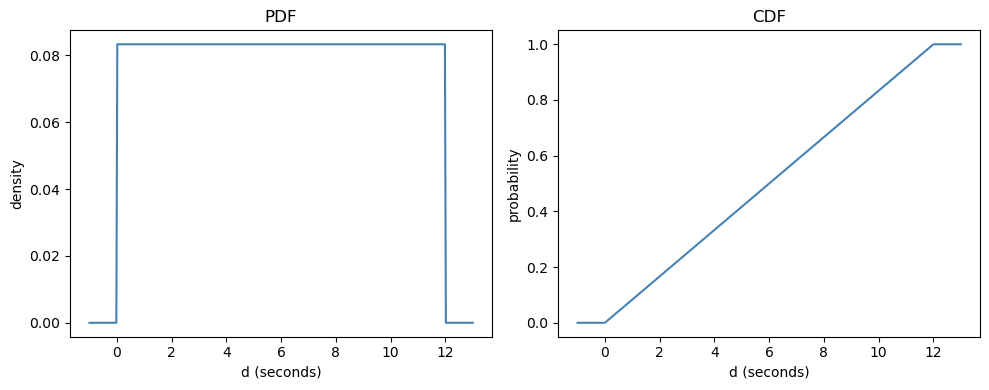

In [11]:
a, b = 0, 12
D = stats.uniform(loc=a, scale=b - a)

d = np.linspace(-1, 13, 400)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(d, D.pdf(d), color="steelblue")
axes[0].set_xlabel("d (seconds)")
axes[0].set_ylabel("density")
axes[0].set_title("PDF")

axes[1].plot(d, D.cdf(d), color="steelblue")
axes[1].set_xlabel("d (seconds)")
axes[1].set_ylabel("probability")
axes[1].set_title("CDF")

plt.tight_layout()
plt.show()

**Support:** $\mathrm{supp}(D) = [0, 12]$ seconds. The delay can fall anywhere in the 12-second
polling cycle, never negative or longer than a full cycle.

**Constant density:** the PDF is flat at $1/12 \approx 0.083$ across $[0,12]$ because the event
is equally likely to occur at any point in the cycle: equal-length subintervals of $[0,12]$ carry
equal probability.

**Why $P(D=d)=0$:** for a continuous variable, probability is *area* under the density. A single
point $d$ has zero width, so it contributes zero area no matter how "likely" that value looks on
the curve. This does not mean $d$ is impossible to observe, only that no single value carries
positive probability mass.

### b)

> Calculate $P(D \le 3)$, $P(4 < D < 9)$, $P(D > 10)$, the mean, standard deviation, and 95th
> percentile.

For $a \le c < d \le b$: $P(c<D<d) = F(d)-F(c) = \dfrac{d-c}{b-a}$, and
$$E[D] = \frac{a+b}{2}, \qquad \text{Var}(D) = \frac{(b-a)^2}{12}$$

$$\text{SD}(D) = \sqrt{\text{Var}(D)}, \qquad q = a + p\,(b - a)$$

In [12]:
PD3 = D.cdf(3)
PD49 = D.cdf(9) - D.cdf(4)
PD10 = D.sf(10)
mean_D, sd_D = D.mean(), D.std()
p95_D = D.ppf(0.95)

print(f"P(D<=3)     = {PD3:.4f}")
print(f"P(4<D<9)    = {PD49:.4f}")
print(f"P(D>10)     = {PD10:.4f}")
print(f"mean        = {mean_D:.4f} s")
print(f"sd          = {sd_D:.4f} s")
print(f"95th pct    = {p95_D:.4f} s")

P(D<=3)     = 0.2500
P(4<D<9)    = 0.4167
P(D>10)     = 0.1667
mean        = 6.0000 s
sd          = 3.4641 s
95th pct    = 11.4000 s


**Interpretation:** A quarter of delays are 3 seconds or less. About 42 % fall strictly between
4 and 9 seconds, and about a sixth exceed 10 seconds. The mean delay is 6 s (the cycle's
midpoint), with a standard deviation of about 3.46 s. 95 % of delays are under 11.4 s.

## Concrete strength: normal working model

> The file `assignment02_concrete_strength.csv` contains 160 compressive-strength measurements.
> Treat the generating parameters as unknown.

### a)

> Report $n$, mean, median, and sample standard deviation. Fit $N(\hat\mu, \hat\sigma^2)$ and
> explain why SciPy receives $\hat\sigma$, not $\hat\sigma^2$, as `scale`.

Let $X$ be the compressive strength (MPa) of a concrete specimen.

In [13]:
n_c = len(concrete)
mu_hat = concrete["strength_mpa"].mean()
median_c = concrete["strength_mpa"].median()
sigma_hat = concrete["strength_mpa"].std()   # sample sd, ddof=1 by default

print(f"n      = {n_c}")
print(f"mean   = {mu_hat:.2f} MPa")
print(f"median = {median_c:.2f} MPa")
print(f"sd     = {sigma_hat:.2f} MPa")

n      = 160
mean   = 42.49 MPa
median = 42.38 MPa
sd     = 4.34 MPa


**Fitted model:** $X \sim N(\hat\mu, \hat\sigma^2)$ with $\hat\mu \approx 42.49$ MPa and
$\hat\sigma^2 \approx 18.86\ \text{MPa}^2$ (i.e. $\hat\sigma \approx 4.34$ MPa).

**Why `scale` is $\hat\sigma$, not $\hat\sigma^2$:** in the mathematical notation $N(\mu,\sigma^2)$
the second parameter is the *variance*. SciPy's `norm` takes `scale`, which is the *standard
deviation* $\sigma$, the spread on the same scale (MPa) as the data. Passing the variance in its
place would make the fitted curve far too wide.

In [14]:
normal_model = stats.norm(loc=mu_hat, scale=sigma_hat)
print(f"fitted N({mu_hat:.2f}, {sigma_hat**2:.2f})")

fitted N(42.49, 18.86)


### b)

> Plot a density histogram with the fitted PDF and create a normal QQ-plot. Discuss symmetry,
> tails, unusual observations, and model adequacy.

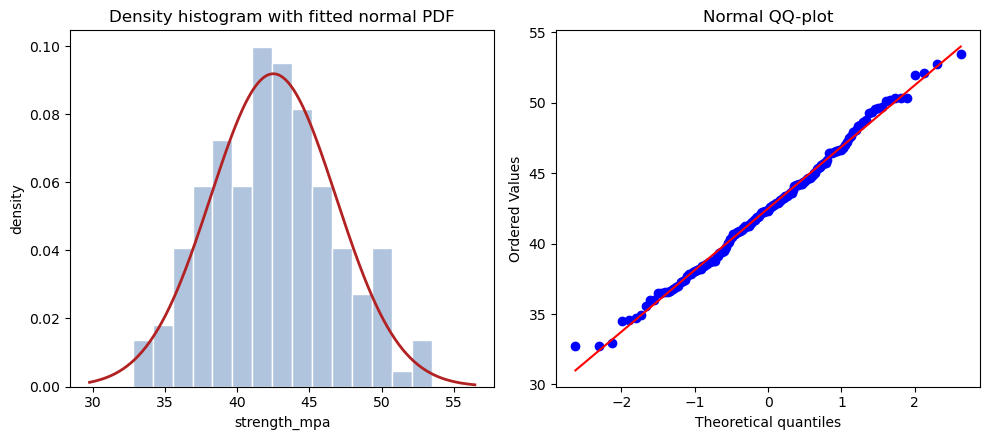

In [15]:
x_grid = np.linspace(concrete["strength_mpa"].min() - 3, concrete["strength_mpa"].max() + 3, 300)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

axes[0].hist(concrete["strength_mpa"], bins=15, density=True, color="lightsteelblue",
             edgecolor="white")
axes[0].plot(x_grid, normal_model.pdf(x_grid), color="firebrick", lw=2)
axes[0].set_xlabel("strength_mpa")
axes[0].set_ylabel("density")
axes[0].set_title("Density histogram with fitted normal PDF")

stats.probplot(concrete["strength_mpa"], dist="norm", plot=axes[1])
axes[1].set_title("Normal QQ-plot")

plt.tight_layout()
plt.show()

**Symmetry:** the histogram is a single, roughly symmetric bell, and the mean (42.49 MPa) is almost
equal to the median (42.38 MPa).

**Tails:** the QQ points follow the line closely, with no S-shape and no upward bending at the right
end. The lowest few points sit slightly above the line, so there are, if anything, slightly fewer
very weak specimens than the normal predicts.

**Unusual observations:** none. No point lies far from the line, and the histogram shows no gaps,
clusters or isolated bars.

**Model adequacy:** a normal working model looks reasonable: one peak, close to symmetric, no heavy
tails and no unusual points. The QQ-plot supports the model but does not prove the data are normal.

### c)

> From the fitted model, calculate $P(X<35)$, $P(38<X<46)$, the 95th percentile, and the
> $z$-score of 35 MPa. Compare the first two model probabilities with empirical proportions.

In [16]:
P_Xlt35 = normal_model.cdf(35)
P_38lt_lt46 = normal_model.cdf(46) - normal_model.cdf(38)
p95_X = normal_model.ppf(0.95)
z_35 = (35 - mu_hat) / sigma_hat

emp_lt35 = (concrete["strength_mpa"] < 35).mean()
emp_38_46 = ((concrete["strength_mpa"] > 38) & (concrete["strength_mpa"] < 46)).mean()

print(f"model  P(X<35)      = {P_Xlt35:.4f}")
print(f"model  P(38<X<46)   = {P_38lt_lt46:.4f}")
print(f"model  95th pct     = {p95_X:.2f} MPa")
print(f"z-score of 35 MPa   = {z_35:.4f}")
print()
print(f"empirical P(X<35)     = {emp_lt35:.4f}")
print(f"empirical P(38<X<46)  = {emp_38_46:.4f}")

model  P(X<35)      = 0.0422
model  P(38<X<46)   = 0.6399
model  95th pct     = 49.64 MPa
z-score of 35 MPa   = -1.7256

empirical P(X<35)     = 0.0437
empirical P(38<X<46)  = 0.6375


**Interpretation:** the fitted model puts about 4.2 % of strengths below 35 MPa and about 64.0 %
between 38 and 46 MPa. The empirical proportions are close, 4.4 % and 63.8 %. 95 % of strengths
are predicted to fall below about 49.6 MPa. A specimen at 35 MPa has $z \approx -1.73$, about 1.73
standard deviations below the fitted mean, an uncommon but not extreme value. The agreement
between model and empirical probabilities supports the model-adequacy conclusion from (b).

<a id="part4"></a>
# Part 4 — Service restoration: an exponential working model

> The file `assignment02_service_repairs.csv` contains 180 restoration times from independent
> service incidents. Treat the rate as unknown.

## a)

> Report $n$, mean, median, sample standard deviation, minimum, and maximum. Plot a density
> histogram and describe the shape.

Let $T$ be the restoration time (minutes) of a service incident.

In [17]:
n_r = len(repairs)
mean_r = repairs["repair_time_min"].mean()
median_r = repairs["repair_time_min"].median()
sd_r = repairs["repair_time_min"].std()
min_r = repairs["repair_time_min"].min()
max_r = repairs["repair_time_min"].max()

print(f"n      = {n_r}")
print(f"mean   = {mean_r:.2f} min")
print(f"median = {median_r:.2f} min")
print(f"sd     = {sd_r:.2f} min")
print(f"min    = {min_r:.2f} min")
print(f"max    = {max_r:.2f} min")

n      = 180
mean   = 69.80 min
median = 49.34 min
sd     = 67.43 min
min    = 1.11 min
max    = 410.66 min


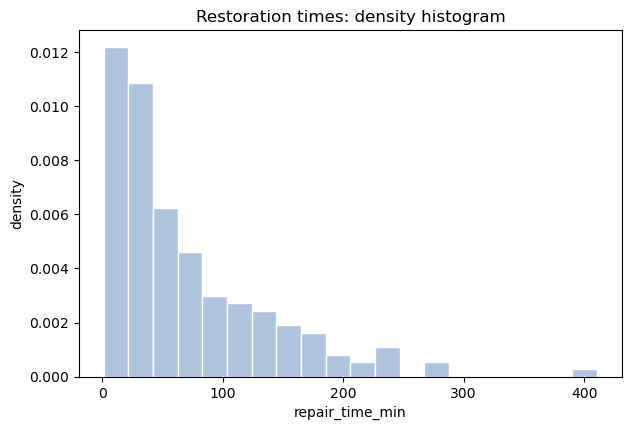

In [18]:
plt.figure(figsize=(7, 4.5))
plt.hist(repairs["repair_time_min"], bins=20, density=True, color="lightsteelblue",
         edgecolor="white")
plt.xlabel("repair_time_min")
plt.ylabel("density")
plt.title("Restoration times: density histogram")
plt.show()

**Shape:** the histogram is tallest near zero and decays steadily to the right, strongly
**right-skewed**, with no negative values (min 1.11 min) and a long tail out to 410.66 min. The
mean (69.80 min) sits well above the median (49.34 min), the usual signature of this skew. The
standard deviation (67.43 min) is close in size to the mean itself, the pattern a waiting-time
process tends to produce.

## b)

> Fit an exponential model using $\hat\lambda = 1/\bar x$. State its fitted rate, mean, variance,
> and SciPy scale and add the fitted PDF to the histogram.

$$\hat\lambda = \frac{1}{\bar x}, \qquad \text{SciPy } \texttt{scale} = \frac{1}{\hat\lambda} = \bar x$$

$$E[T] = \frac{1}{\lambda}, \qquad \text{Var}(T) = \frac{1}{\lambda^2}$$

In [19]:
lambda_hat = 1 / mean_r
expon_scale = 1 / lambda_hat   # = mean_r

exp_model = stats.expon(scale=expon_scale)

print(f"lambda_hat   = {lambda_hat:.5f} per minute")
print(f"scale        = {expon_scale:.2f} min")
print(f"fitted mean  = {exp_model.mean():.2f} min")
print(f"fitted var   = {exp_model.var():.2f} min^2")

lambda_hat   = 0.01433 per minute
scale        = 69.80 min
fitted mean  = 69.80 min
fitted var   = 4871.85 min^2


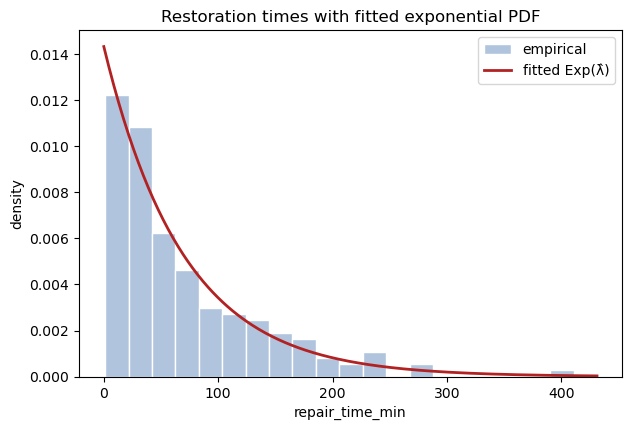

In [20]:
t_grid = np.linspace(0, repairs["repair_time_min"].max() * 1.05, 300)

plt.figure(figsize=(7, 4.5))
plt.hist(repairs["repair_time_min"], bins=20, density=True, color="lightsteelblue",
         edgecolor="white", label="empirical")
plt.plot(t_grid, exp_model.pdf(t_grid), color="firebrick", lw=2, label="fitted Exp(λ̂)")
plt.xlabel("repair_time_min")
plt.ylabel("density")
plt.title("Restoration times with fitted exponential PDF")
plt.legend()
plt.show()

**Interpretation:** the fitted rate is about 0.0143 restorations completed per minute of elapsed
repair time. By construction, the fitted mean (69.80 min) matches the sample mean. The fitted
variance is about 4871.8 min². The fitted PDF traces the same decaying shape as the histogram:
highest density near zero, falling off toward the long tail.

## c)

> Compare empirical and fitted distributions using an empirical CDF with fitted CDF or an
> exponential QQ-plot. Discuss model strengths and limitations.

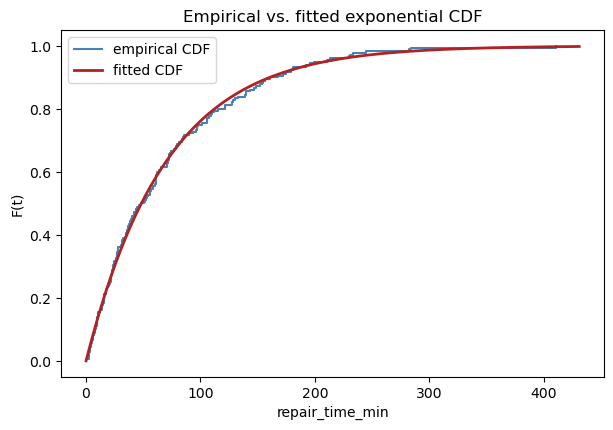

In [21]:
sorted_t = np.sort(repairs["repair_time_min"])
ecdf_y = np.arange(1, n_r + 1) / n_r

plt.figure(figsize=(7, 4.5))
plt.step(sorted_t, ecdf_y, where="post", color="steelblue", label="empirical CDF")
plt.plot(t_grid, exp_model.cdf(t_grid), color="firebrick", lw=2, label="fitted CDF")
plt.xlabel("repair_time_min")
plt.ylabel("F(t)")
plt.title("Empirical vs. fitted exponential CDF")
plt.legend()
plt.show()

**Strengths:** the fitted CDF tracks the empirical step function closely across almost the whole
range. The exponential model captures the strong right skew, the near-zero minimum, and the long
tail well, without extra parameters.

**Limitations:** the exponential model puts the highest density at $t=0$, treating an instant
restoration as the most likely outcome. Real repairs usually need some minimum time for diagnosis
and travel, so a small positive floor is plausible, even though the data's minimum (1.11 min) is
close to zero. The model also assumes a **constant** completion rate throughout a repair (see e).
If repairs instead get harder or easier the longer they run, the exponential shape would misstate
the tail.

## d)

> Calculate and interpret $P(T \le 30)$, $P(T>120)$, the median, and the 90th percentile.
> Compare the two model probabilities with empirical proportions.

In [22]:
P_Tle30 = exp_model.cdf(30)
P_Tgt120 = exp_model.sf(120)
median_T = exp_model.median()
p90_T = exp_model.ppf(0.90)

emp_le30 = (repairs["repair_time_min"] <= 30).mean()
emp_gt120 = (repairs["repair_time_min"] > 120).mean()

print(f"model      P(T<=30)   = {P_Tle30:.4f}")
print(f"model      P(T>120)   = {P_Tgt120:.4f}")
print(f"model      median     = {median_T:.2f} min")
print(f"model      90th pct   = {p90_T:.2f} min")
print()
print(f"empirical  P(T<=30)   = {emp_le30:.4f}")
print(f"empirical  P(T>120)   = {emp_gt120:.4f}")

model      P(T<=30)   = 0.3494
model      P(T>120)   = 0.1792
model      median     = 48.38 min
model      90th pct   = 160.72 min

empirical  P(T<=30)   = 0.3611
empirical  P(T>120)   = 0.2000


**Interpretation:** the model predicts about 34.9 % of repairs finish within 30 minutes (observed:
36.1 %) and about 17.9 % take more than 120 minutes (observed: 20.0 %). Both are reasonably close,
though the model slightly *understates* the long tail, matching the limitation noted in (c). The
fitted median is 48.38 min, close to the sample median (49.34 min). 90 % of restorations are
predicted to finish within about 160.7 min.

## e)

> Calculate $P(T>150 \mid T>60)$ as both a ratio of survival probabilities and the probability of
> waiting an additional 90 minutes. Explain the memoryless and constant-rate assumptions.

$$P(T>150 \mid T>60) = \frac{P(T>150)}{P(T>60)} = \frac{S(150)}{S(60)}$$

By the memoryless property of the exponential distribution,
$P(T>s+t \mid T>s) = P(T>t)$, so with $s=60$ and $t=90$ this also equals $P(T>90)$ directly.

In [23]:
ratio_form = exp_model.sf(150) / exp_model.sf(60)
direct_form = exp_model.sf(90)

print(f"S(150)/S(60)      = {ratio_form:.4f}")
print(f"P(T>90) directly  = {direct_form:.4f}")

S(150)/S(60)      = 0.2754
P(T>90) directly  = 0.2754


**Interpretation:** both routes give the same value, about 0.2754. Having already waited 60
minutes without a restoration tells us nothing about how much longer it will take. The wait
resets, and the extra time behaves like a fresh $T$.

**Why this holds:** the memoryless property follows because the exponential model assumes a
**constant restoration rate** $\lambda$ throughout a repair: the chance of finishing in the next
instant does not depend on how long the technician has already worked. This could fail in
practice. Repairs still open after an hour might be genuinely harder cases (rate decreasing with
elapsed time), or mostly done and close to completion (rate increasing). Either would break the
constant-rate assumption and the memoryless property with it.

<a id="part5"></a>
# Part 5 — AI-use and conclusion

## AI-use

> State which AI tools you used, what they contributed, what you changed or rejected, and how you
> verified the result. A short paragraph or table is sufficient. If AI produced most of the code or
> text, state this honestly.

**Tool used:** Claude.

**What it contributed:** help with the Python code: syntax, turning probability statements into
SciPy functions, checking SciPy parameters and debugging plots. It also helped rephrase our Markdown
text and improve its grammar and vocabulary, and we used it to check that our calculations were
correct.

**What we changed or rejected:** we removed statistics the lectures do not cover, such as skewness
and kurtosis, and cut explanations that went beyond what each question asked.

**How we verified the result:** we compared our results with the worked examples in the lecture
notes and checked SciPy's answers against the formulas worked by hand. The notebook was re-executed
from a clean state so that every cell runs in order with its output visible.

## Overall conclusion

_To be completed._